# Networked Koopman Operator and Dynamic Topology

Dynamic-topology support in KoopmanGraph already lets `predict(..., future_topologies=...)`
change the **decode** graph mid-horizon. With the default per-node operator, though,
the **linear** step is still `z @ K.T` independently at every node — so rewiring never
touches latent advance itself.

Related work uses block structure inside the linear map itself. Li et al. (2020) learn
compositional / object-centric Koopman models whose relation-typed blocks `K_ij`
share parameters across equivalent interactions (off-diagonal blocks carry coupling;
their `Diag` ablation zeros those blocks). Mukherjee et al. (2022) learn distributed
geometric Koopman operators on sparse networks, with agent-level blocks and
`A_ij = 0` for non-neighbors. This notebook studies a simpler shared self/neighbor
factorization, `I ⊗ K_self + Â ⊗ K_nbr`, and asks whether topology still enters the
**linear** step under mid-horizon rewiring.

> **Primary question:** under a mid-horizon path→ring rewire, does `koopman="graph"`
> change **latent advance** in a way that `koopman="pernode"` cannot?

We train matched Schur-parameterized models with a conservative factor radius so
rollouts stay finite, then use latent `|Δz|` as the decisive check. Physical
panels are a **sanity check** (no blow-up; coarse RMSE), not a claim of accurate
long-horizon path forecasting. Spectrum panels show how the effective networked
operator depends on `Â` (often modestly when `K_nbr` is small).


## Methodology

| Setting | What it does |
|---------|----------------|
| `koopman="pernode"` | Same `K` at every node: `z_{t+1} = z_t @ K.T`. Topology enters encode/decode only. |
| `koopman="graph"` | Networked step `Z @ K_self.T + (Â Z) @ K_nbr.T` with symmetric-normalized adjacency `Â`. Topology enters the **linear** step every rollout tick. |

**Protocol**

1. Generate a path-graph diffusion trajectory (`SyntheticDynamicGraphBenchmark`).
2. Fit matched `GraphKoopmanModel` instances with `koopman_parameterization="schur"`
   and `koopman_max_spectral_radius=0.7`. Factor bounds do not certify the effective
   Kronecker sum, so the tighter margin keeps multi-step rollouts finite.
3. From a mid-sequence origin, roll out with (a) hold-last path edges and (b) known
   future **ring** topologies.
4. Decide the primary question with **latent** path-vs-ring advances (no decode).
   Use physical RMSE / fields only as a finite-forecast sanity check, and spectrum
   overlays for the effective `N*d` operator on each adjacency.

**Caveats**

- Training never sees the ring. Changing `future_topologies` also changes the
  **decoder** graph for both models, so a small physical `|hold − ring|` gap is
  expected even for `pernode`. That is **not** evidence of networked linear coupling.
- Structural modes bound `K_self` / `K_nbr` only; the effective
  `I ⊗ K_self + Â ⊗ K_nbr` can still exceed those factor bounds. The demo
  uses `max_spectral_radius=0.7` to leave margin for coupling.
- Quick-run vs full-demo budgets are controlled by the `EPOCHS` variable below.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.graph_utils import dense_symmetric_normalized_adjacency

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
SEED = 0
torch.manual_seed(SEED)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "font.size": 10,
    }
)


## Set up the problem

Build a path-diffusion sequence, then construct the alternate **ring** edge set used
only at forecast time. The origin is the last path snapshot before the rewire;
targets are the remaining timesteps (still generated on the path).


In [2]:
NUM_NODES = 12
IN_CHANNELS = 2
LATENT_DIM = 8
SPLIT = 15
FEATURE = 0
NODE_ID = NUM_NODES // 2
PARAM = "schur"
# Factor bounds do not certify ρ(I⊗K_self + Â⊗K_nbr). Keep a margin so the
# interactive (40-epoch) demo stays contractive on the path adjacency.
MAX_RHO = 0.7

seq = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=30,
    in_channels=IN_CHANNELS,
    topology="path",
    seed=SEED,
    noise_std=0.0,
)

ring_edges: list[list[int]] = []
for i in range(NUM_NODES):
    j = (i + 1) % NUM_NODES
    ring_edges.extend([[i, j], [j, i]])
ring_edge_index = torch.tensor(ring_edges, dtype=torch.long).t().contiguous()
path_edge_index = seq[0].edge_index

origin = seq[SPLIT - 1]
targets = list(seq[SPLIT:])
horizon = len(targets)
future_topologies = [
    Data(x=seq[t].x, edge_index=ring_edge_index) for t in range(SPLIT, len(seq))
]

print(
    f"sequence length={len(seq)}, origin t={SPLIT - 1}, "
    f"forecast horizon={horizon}, train topology=path, shock=ring"
)
print(f"operator parameterization={PARAM}, max_spectral_radius={MAX_RHO}")


sequence length=30, origin t=14, forecast horizon=15, train topology=path, shock=ring
operator parameterization=schur, max_spectral_radius=0.7


### Visualize the topology shock

Path (training / hold-last) vs ring (known future). The adjacency heatmaps show how
normalized coupling `Â` changes when the contacts close into a loop — including
renormalization of the old endpoint edges.


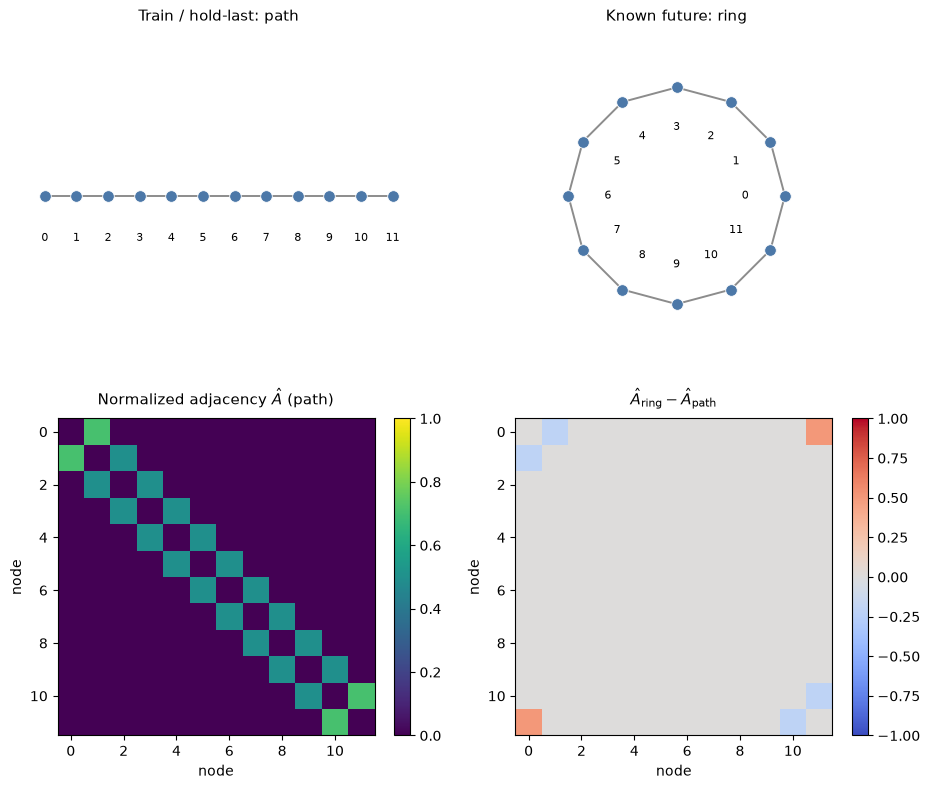

In [3]:
def draw_graph(ax, edge_index: torch.Tensor, *, title: str, layout: str) -> None:
    """Draw a simple undirected graph without networkx."""
    if layout == "path":
        y0 = 0.0
        pos = {i: (float(i), y0) for i in range(NUM_NODES)}
        label_xy = {i: (float(i), y0 - 0.22) for i in range(NUM_NODES)}
        label_va = "top"
    else:
        # Labels sit inside the ring so they cannot collide with the title.
        radius = 0.82
        label_radius = 0.52
        angles = np.linspace(0.0, 2.0 * np.pi, NUM_NODES, endpoint=False)
        pos = {
            i: (radius * np.cos(theta), radius * np.sin(theta))
            for i, theta in enumerate(angles)
        }
        label_xy = {
            i: (label_radius * np.cos(theta), label_radius * np.sin(theta))
            for i, theta in enumerate(angles)
        }
        label_va = "center"

    seen: set[tuple[int, int]] = set()
    for src, dst in edge_index.t().tolist():
        edge = (min(src, dst), max(src, dst))
        if edge in seen:
            continue
        seen.add(edge)
        x0, y0_ = pos[src]
        x1, y1_ = pos[dst]
        ax.plot([x0, x1], [y0_, y1_], color="0.55", linewidth=1.4, zorder=1)

    xs = [pos[i][0] for i in range(NUM_NODES)]
    ys = [pos[i][1] for i in range(NUM_NODES)]
    ax.scatter(xs, ys, s=70, c="#4C78A8", zorder=2, edgecolors="white", linewidths=0.6)
    for i in range(NUM_NODES):
        lx, ly = label_xy[i]
        ax.text(lx, ly, str(i), ha="center", va=label_va, fontsize=8, clip_on=True)

    if layout == "path":
        # Auto aspect: path is 1-D, equal-aspect was collapsing title headroom.
        ax.set_xlim(-0.6, NUM_NODES - 0.4)
        ax.set_ylim(-0.95, 0.95)
        ax.set_aspect("auto")
    else:
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_aspect("equal", adjustable="box")

    ax.set_title(title, pad=12)
    ax.axis("off")


adj_path = dense_symmetric_normalized_adjacency(
    path_edge_index, NUM_NODES, dtype=torch.float32
).numpy()
adj_ring = dense_symmetric_normalized_adjacency(
    ring_edge_index, NUM_NODES, dtype=torch.float32
).numpy()

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.0))
draw_graph(axes[0, 0], path_edge_index, title="Train / hold-last: path", layout="path")
draw_graph(axes[0, 1], ring_edge_index, title="Known future: ring", layout="ring")

im0 = axes[1, 0].imshow(adj_path, cmap="viridis", vmin=0.0, vmax=1.0)
axes[1, 0].set_title(r"Normalized adjacency $\hat{A}$ (path)", pad=10)
axes[1, 0].set_xlabel("node")
axes[1, 0].set_ylabel("node")
fig.colorbar(im0, ax=axes[1, 0], fraction=0.046)

im1 = axes[1, 1].imshow(adj_ring - adj_path, cmap="coolwarm", vmin=-1.0, vmax=1.0)
axes[1, 1].set_title(r"$\hat{A}_{\mathrm{ring}} - \hat{A}_{\mathrm{path}}$", pad=10)
axes[1, 1].set_xlabel("node")
axes[1, 1].set_ylabel("node")
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046)
fig.tight_layout(h_pad=2.4, w_pad=1.2)
plt.show()


## Run calculations

Fit both Schur-parameterized models, then evaluate hold-last vs known-ring rollouts.
The decisive statistic is the **latent** path-vs-ring gap curve (encode once, advance
twice with different `edge_index`, never decode).


In [4]:
def make_model(kind: str) -> GraphKoopmanModel:
    return GraphKoopmanModel(
        encoder=GNNEncoder(IN_CHANNELS, 16, LATENT_DIM, num_layers=2),
        decoder=GNNDecoder(LATENT_DIM, 16, IN_CHANNELS, num_layers=2),
        latent_dim=LATENT_DIM,
        time_step=0.1,
        koopman=kind,
        koopman_parameterization=PARAM,
        koopman_max_spectral_radius=MAX_RHO,
    )


def mean_rmse(preds, target_snaps) -> float:
    errors = [
        (pred.x - target.x).pow(2).mean().sqrt()
        for pred, target in zip(preds, target_snaps, strict=True)
    ]
    return float(torch.stack(errors).mean())


def field_matrix(snaps) -> np.ndarray:
    """Stack node values for one feature into shape (num_nodes, time)."""
    return torch.stack([snap.x[:, FEATURE] for snap in snaps], dim=1).detach().numpy()


@torch.no_grad()
def latent_gap_curve(model: GraphKoopmanModel) -> np.ndarray:
    """Per-step mean |z_path - z_ring| under fixed-topology latent rollouts."""
    z_path = model.encode(origin)
    z_ring = z_path.clone()
    gaps = []
    for _ in range(horizon):
        z_path = model.koopman.advance(z_path, edge_index=path_edge_index)
        z_ring = model.koopman.advance(z_ring, edge_index=ring_edge_index)
        gaps.append(float((z_path - z_ring).abs().mean().detach()))
    return np.asarray(gaps)


epochs = 8 if CI else 40
models = {
    "pernode": make_model("pernode"),
    "graph": make_model("graph"),
}
histories = {
    name: model.fit(seq, epochs=epochs, lr=1e-2) for name, model in models.items()
}

predictions: dict[str, dict[str, list]] = {}
gap_curves: dict[str, np.ndarray] = {}
rows: list[dict[str, float | str]] = []

for name, model in models.items():
    hold = model.predict(origin, steps=horizon)
    rewire = model.predict(
        origin, steps=horizon, future_topologies=future_topologies
    )
    predictions[name] = {"hold": hold, "ring": rewire}
    gap_curves[name] = latent_gap_curve(model)

    with torch.no_grad():
        z0 = model.encode(origin)
        z_path = model.koopman.advance(z0, edge_index=path_edge_index)
        z_ring = model.koopman.advance(z0, edge_index=ring_edge_index)
        one_step_gap = float((z_path - z_ring).abs().mean().detach())

    rows.append(
        {
            "model": name,
            "final_train_loss": float(histories[name].loss[-1]),
            "rmse_hold_path": mean_rmse(hold, targets),
            "rmse_known_ring": mean_rmse(rewire, targets),
            "latent_advance_gap": one_step_gap,
        }
    )

graph_model = models["graph"]
spec_path = graph_model.koopman.spectrum(path_edge_index, NUM_NODES)
spec_ring = graph_model.koopman.spectrum(ring_edge_index, NUM_NODES)
truth_field = field_matrix(targets)

row_by_name = {str(row["model"]): row for row in rows}
assert float(row_by_name["pernode"]["latent_advance_gap"]) < 1e-6
assert float(row_by_name["graph"]["latent_advance_gap"]) > 1e-6
assert gap_curves["pernode"].max() < 1e-6
assert gap_curves["graph"].max() > 1e-6
# Stable demo: both models should track path targets under hold-last.
hold_pernode = float(row_by_name["pernode"]["rmse_hold_path"])
hold_graph = float(row_by_name["graph"]["rmse_hold_path"])
assert hold_pernode < 0.25, f"pernode hold RMSE too high: {hold_pernode:.4f}"
assert hold_graph < 0.25, f"graph hold RMSE too high: {hold_graph:.4f}"


## Display results

Read the panels in order: summary metrics → latent gap curve (primary) → physical
sanity checks → effective spectrum (secondary).


### Summary metrics

Left: one-step latent gap (primary claim). Right: forecast RMSE vs path targets
(sanity check that both models stayed finite — not a coupling test).


model      train_loss    RMSE hold    RMSE ring    |Δz| 1-step
pernode        0.0038       0.0814       0.0835      0.000e+00
graph          0.0039       0.0584       0.0629      1.774e-03


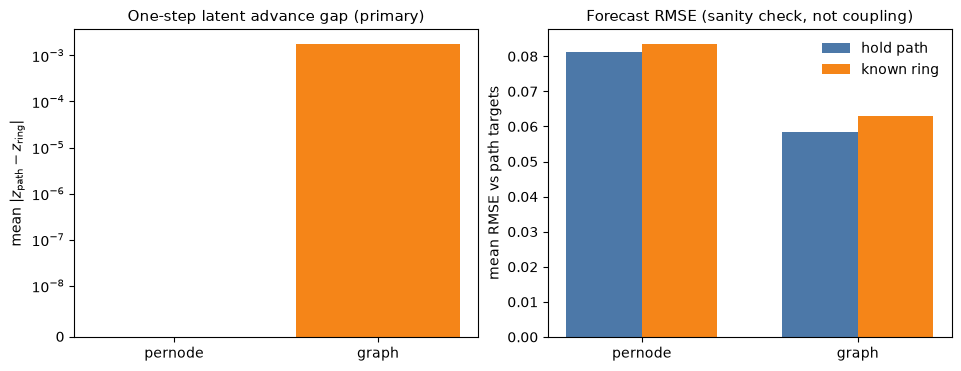

In [5]:
print(
    f"{'model':8s} {'train_loss':>12s} {'RMSE hold':>12s} "
    f"{'RMSE ring':>12s} {'|Δz| 1-step':>14s}"
)
for row in rows:
    print(
        f"{row['model']:8s} "
        f"{row['final_train_loss']:12.4f} "
        f"{row['rmse_hold_path']:12.4f} "
        f"{row['rmse_known_ring']:12.4f} "
        f"{row['latent_advance_gap']:14.3e}"
    )

labels = [str(row["model"]) for row in rows]
gaps = [float(row["latent_advance_gap"]) for row in rows]
hold_rmse = [float(row["rmse_hold_path"]) for row in rows]
ring_rmse = [float(row["rmse_known_ring"]) for row in rows]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), constrained_layout=True)
axes[0].bar(labels, gaps, color=["#4C78A8", "#F58518"])
axes[0].set_ylabel(r"mean $|z_{\mathrm{path}} - z_{\mathrm{ring}}|$")
axes[0].set_title("One-step latent advance gap (primary)")
axes[0].set_yscale("symlog", linthresh=1e-8)

x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width / 2, hold_rmse, width, label="hold path", color="#4C78A8")
axes[1].bar(x + width / 2, ring_rmse, width, label="known ring", color="#F58518")
axes[1].set_xticks(x, labels)
axes[1].set_ylabel("mean RMSE vs path targets")
axes[1].set_title("Forecast RMSE (sanity check, not coupling)")
axes[1].legend(frameon=False)
plt.show()


### Latent advance gap over the horizon (decisive evidence)

Encode once at the origin, then advance two latent copies — one under path edges,
one under ring edges — with **no** decode. `pernode` must stay at numerical zero;
`graph` must separate. This is the direct answer to the notebook question.


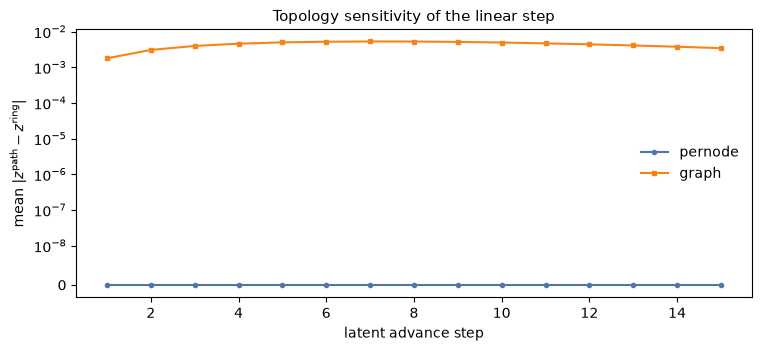

In [6]:
steps = np.arange(1, horizon + 1)
fig, ax = plt.subplots(figsize=(7.5, 3.4), constrained_layout=True)
ax.plot(
    steps,
    gap_curves["pernode"],
    marker="o",
    markersize=3,
    color="#4C78A8",
    label="pernode",
)
ax.plot(
    steps,
    gap_curves["graph"],
    marker="s",
    markersize=3,
    color="#F58518",
    label="graph",
)
ax.set_xlabel("latent advance step")
ax.set_ylabel(r"mean $|z^{\mathrm{path}} - z^{\mathrm{ring}}|$")
ax.set_title("Topology sensitivity of the linear step")
ax.set_yscale("symlog", linthresh=1e-8)
ax.legend(frameon=False)
plt.show()


### Physical forecasts: finite rollouts under hold-path

These panels are a **sanity check**, not the coupling test. With the conservative
Schur factor bound, both models stay finite and pass a coarse mean-RMSE gate, but
they typically **damp faster** than the true path diffusion over the forecast horizon.

The `|ring − hold|` maps are mostly **endpoint-dominated** (decoder sees the rewire
at nodes 0/11). A small gap for `pernode` is expected from decode-only topology
changes. A somewhat larger / more persistent gap for `graph` is consistent with
decode **plus** linear coupling — still secondary to the latent `|Δz|` curve above.


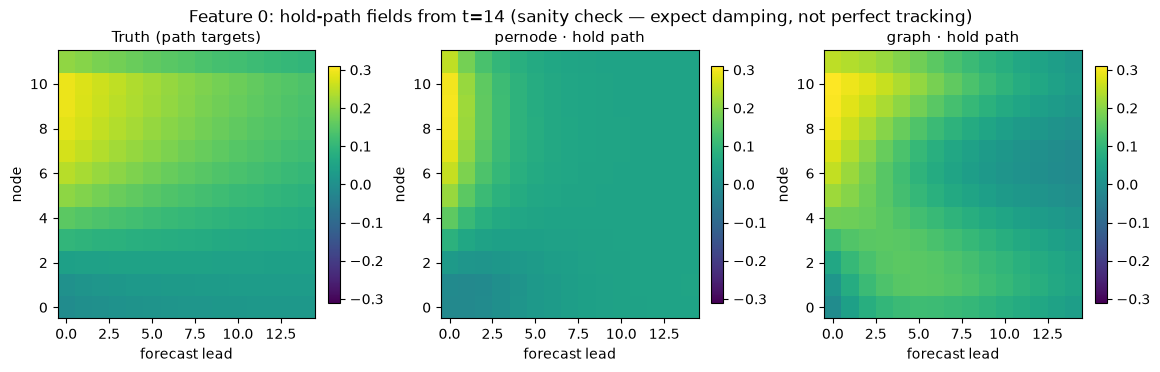

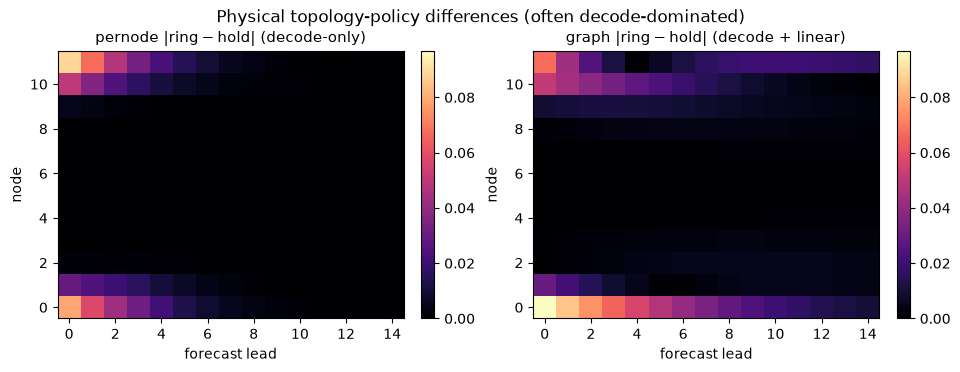

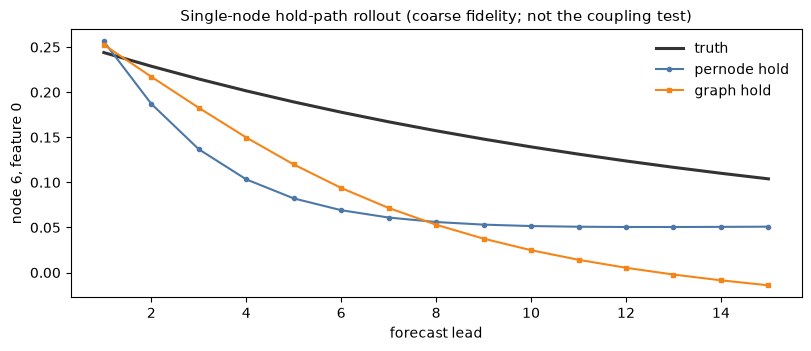

In [7]:
hold_fields = {
    "Truth (path targets)": truth_field,
    "pernode · hold path": field_matrix(predictions["pernode"]["hold"]),
    "graph · hold path": field_matrix(predictions["graph"]["hold"]),
}
vmax = max(float(np.abs(field).max()) for field in hold_fields.values())
vmax = max(vmax, 1e-3)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), constrained_layout=True)
for ax, (title, field) in zip(axes, hold_fields.items(), strict=True):
    im = ax.imshow(
        field,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("forecast lead")
    ax.set_ylabel("node")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(
    f"Feature {FEATURE}: hold-path fields from t={SPLIT - 1} "
    "(sanity check — expect damping, not perfect tracking)",
    y=1.05,
)
plt.show()

diff_pernode = np.abs(
    field_matrix(predictions["pernode"]["ring"])
    - field_matrix(predictions["pernode"]["hold"])
)
diff_graph = np.abs(
    field_matrix(predictions["graph"]["ring"])
    - field_matrix(predictions["graph"]["hold"])
)
dmax = max(float(diff_pernode.max()), float(diff_graph.max()), 1e-3)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), constrained_layout=True)
im0 = axes[0].imshow(diff_pernode, aspect="auto", origin="lower", cmap="magma", vmin=0.0, vmax=dmax)
axes[0].set_title(r"pernode $|\mathrm{ring}-\mathrm{hold}|$ (decode-only)")
axes[0].set_xlabel("forecast lead")
axes[0].set_ylabel("node")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(diff_graph, aspect="auto", origin="lower", cmap="magma", vmin=0.0, vmax=dmax)
axes[1].set_title(r"graph $|\mathrm{ring}-\mathrm{hold}|$ (decode + linear)")
axes[1].set_xlabel("forecast lead")
axes[1].set_ylabel("node")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.suptitle("Physical topology-policy differences (often decode-dominated)", y=1.05)
plt.show()

lead = np.arange(1, horizon + 1)
fig, ax = plt.subplots(figsize=(8.0, 3.4), constrained_layout=True)
ax.plot(lead, truth_field[NODE_ID], color="0.2", linewidth=2.2, label="truth")
ax.plot(
    lead,
    field_matrix(predictions["pernode"]["hold"])[NODE_ID],
    marker="o",
    markersize=3,
    color="#4C78A8",
    label="pernode hold",
)
ax.plot(
    lead,
    field_matrix(predictions["graph"]["hold"])[NODE_ID],
    marker="s",
    markersize=3,
    color="#F58518",
    label="graph hold",
)
ax.set_xlabel("forecast lead")
ax.set_ylabel(f"node {NODE_ID}, feature {FEATURE}")
ax.set_title("Single-node hold-path rollout (coarse fidelity; not the coupling test)")
ax.legend(frameon=False)
plt.show()


### Effective spectrum of `GraphKoopmanOperator`

Eigenvalues of `I ⊗ K_self + Â ⊗ K_nbr`. Path and ring spectra are often nearly
coincident when `K_nbr` is modest, so the overlay uses open ring markers with
filled path markers plus a zoom inset. The **sorted-magnitude difference** is the
honest quantitative visual; latent `|Δz|` remains the decisive coupling check.


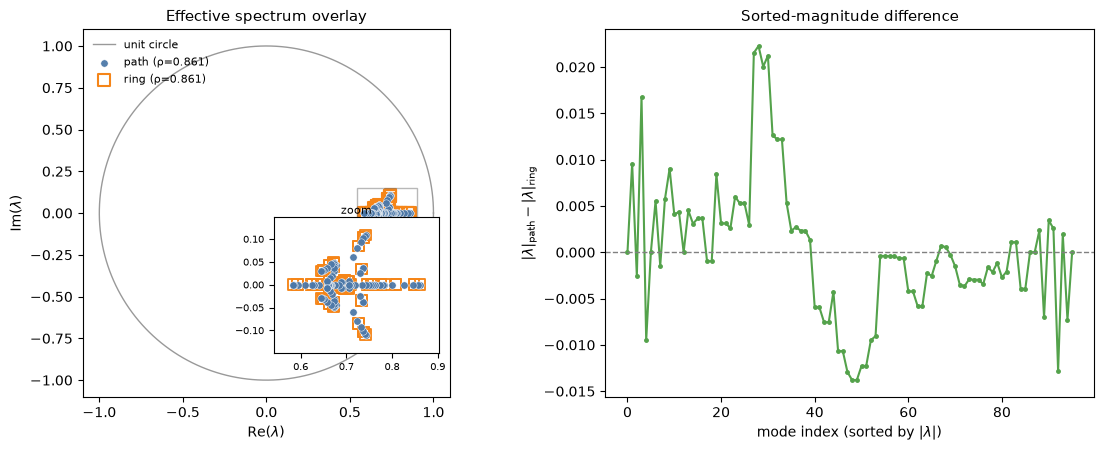

max |sorted |λ| difference| = 2.2265e-02; Hausdorff distance between eigenvalue sets = 2.8137e-02


In [8]:
# Use spectrum magnitudes (already sorted by descending |λ|). Avoid element-wise
# complex eig_path - eig_ring: independent sorts can mis-pair conjugate modes.
eig_path = np.asarray(spec_path.eigenvalues.detach().cpu().numpy(), dtype=np.complex128)
eig_ring = np.asarray(spec_ring.eigenvalues.detach().cpu().numpy(), dtype=np.complex128)
mag_path = np.asarray(spec_path.magnitudes.detach().cpu().numpy(), dtype=np.float64)
mag_ring = np.asarray(spec_ring.magnitudes.detach().cpu().numpy(), dtype=np.float64)
mag_diff = mag_path - mag_ring

# Set distance: for each path eigenvalue, nearest ring eigenvalue (and vice versa).
def _eigset_hausdorff(a: np.ndarray, b: np.ndarray) -> float:
    d_ab = np.max([np.min(np.abs(a_i - b)) for a_i in a])
    d_ba = np.max([np.min(np.abs(b_j - a)) for b_j in b])
    return float(max(d_ab, d_ba))


hausdorff = _eigset_hausdorff(eig_path, eig_ring)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), constrained_layout=True)

theta = np.linspace(0.0, 2.0 * np.pi, 400)
axes[0].plot(np.cos(theta), np.sin(theta), color="0.6", linewidth=1.0, label="unit circle")
# Near-coincident spectra: draw open ring first, then filled path on top; zoom inset for detail.
axes[0].scatter(
    eig_ring.real,
    eig_ring.imag,
    s=70,
    facecolors="none",
    edgecolors="#F58518",
    linewidths=1.5,
    marker="s",
    label=f"ring (ρ={mag_ring[0]:.3f})",
    zorder=3,
)
axes[0].scatter(
    eig_path.real,
    eig_path.imag,
    s=28,
    c="#4C78A8",
    alpha=0.95,
    marker="o",
    edgecolors="white",
    linewidths=0.35,
    label=f"path (ρ={mag_path[0]:.3f})",
    zorder=4,
)
axes[0].set_xlabel(r"$\mathrm{Re}(\lambda)$")
axes[0].set_ylabel(r"$\mathrm{Im}(\lambda)$")
axes[0].set_title("Effective spectrum overlay")
axes[0].set_aspect("equal")
_handles, _labels = axes[0].get_legend_handles_labels()
# Plot order is circle → ring → path; legend as circle → path → ring.
axes[0].legend(
    [_handles[0], _handles[2], _handles[1]],
    [_labels[0], _labels[2], _labels[1]],
    frameon=False,
    fontsize=8,
    loc="upper left",
)

# Zoom where the eigenvalues actually live so path vs ring is readable.
re_all = np.concatenate([eig_path.real, eig_ring.real])
im_all = np.concatenate([eig_path.imag, eig_ring.imag])
re_pad = max(0.04, 0.15 * (re_all.max() - re_all.min() + 1e-6))
im_pad = max(0.04, 0.15 * (im_all.max() - im_all.min() + 1e-6))
axins = axes[0].inset_axes([0.52, 0.08, 0.45, 0.45])
axins.scatter(
    eig_ring.real,
    eig_ring.imag,
    s=58,
    facecolors="none",
    edgecolors="#F58518",
    linewidths=1.35,
    marker="s",
    zorder=3,
)
axins.scatter(
    eig_path.real,
    eig_path.imag,
    s=28,
    c="#4C78A8",
    alpha=0.95,
    marker="o",
    edgecolors="white",
    linewidths=0.35,
    zorder=4,
)
axins.set_xlim(re_all.min() - re_pad, re_all.max() + re_pad)
axins.set_ylim(im_all.min() - im_pad, im_all.max() + im_pad)
axins.set_aspect("equal")
axins.set_title("zoom", fontsize=8, pad=2)
axins.tick_params(labelsize=7)
axes[0].indicate_inset_zoom(axins, edgecolor="0.45")

axes[1].plot(mag_diff, color="#54A24B", marker="o", markersize=2.5)
axes[1].axhline(0.0, color="0.5", linestyle="--", linewidth=1.0)
axes[1].set_xlabel(r"mode index (sorted by $|\lambda|$)")
axes[1].set_ylabel(r"$|\lambda|_{\mathrm{path}} - |\lambda|_{\mathrm{ring}}$")
axes[1].set_title("Sorted-magnitude difference")
plt.show()

print(
    f"max |sorted |λ| difference| = {np.max(np.abs(mag_diff)):.4e}; "
    f"Hausdorff distance between eigenvalue sets = {hausdorff:.4e}"
)


## Interpret the results

- **Topology shock.** Path vs ring layouts and `Â` differences show the adjacency
  change fed into the networked linear step: new wrap-around edges at `(0,11)` /
  `(11,0)`, plus renormalization of the old terminal edges.
- **Latent `|Δz|(t)` (primary).** `pernode` stays at numerical zero; `graph`
  separates at roughly `10^{-3}` and stays separated over the horizon. That answers
  the notebook question: topology enters the linear step only for `koopman="graph"`.
- **Hold-path physical fields.** Both models stay finite (no spectral blow-up) and
  pass a coarse mean-RMSE gate, but **neither** reproduces the slow path diffusion
  over the forecast horizon — both damp too fast (see the single-node panel). Treat
  physical panels as stability/sanity checks, not as evidence of accurate forecasting.
- **Physical `|ring − hold|` maps.** Both are **endpoint-dominated** (decode shock
  at nodes 0/11). The `graph` map is somewhat larger and more persistent because
  decode *and* linear coupling see the ring; still secondary to latent `|Δz|`.
- **Spectrum.** Path and ring usually share nearly the same spectral radius; the
  sorted-magnitude difference / set distance is the honest visual that `Â` enters
  `I⊗K_self + Â⊗K_nbr`. With modest `||K_nbr||/||K_self||`, shifts stay small —
  latent `|Δz|` remains the decisive coupling diagnostic.


## Takeaways

- **Goal revisited:** `koopman="graph"` makes mid-horizon rewiring affect the
  **linear** Koopman step; `koopman="pernode"` ignores topology in that step.
- **Decisive evidence:** near-zero vs nonzero latent `|Δz|(t)` under path vs ring
  advances with no decode.
- **Supporting checks:** hold-path forecasts stay finite for both models (coarse
  RMSE gate); physical `|ring−hold|` is mostly decode-dominated; effective spectra
  can shift with `Â`, often only modestly.
- **Relation to literature:** Li et al. (2020) motivate relation-typed compositional
  blocks; Mukherjee et al. (2022) motivate sparse agent-block operators with
  non-neighbor zeros. This demo is a shared `K_self`/`K_nbr` factorization with
  explicit `Â` — not a reproduction of their rope/control or multi-agent NDS results.
- **API:** `GraphKoopmanModel(..., koopman="graph", koopman_parameterization="schur")`
  (or inject a `GraphKoopmanOperator`); pass `future_topologies` into `predict`.
- **Next steps:** train on sequences that themselves rewire
  (`allow_dynamic_topology=True`); compare notebook 09 topology ablations and
  notebook 13 online adaptation under topology shock.
